In [1]:
import torch
import numpy as np
import os
from glob import glob
from tqdm import tqdm
from pathlib import Path
from PIL import Image
from matplotlib import pyplot as plt
import h5py

In [2]:
data_folder = Path("/media/dhruv/a7519aee-b272-44ae-a117-1f1ea1796db6/2024/NAMO/test1/data_h5/0")
data_files = data_folder.glob("*.h5")
time_taken = []
for i in data_files:
    data = h5py.File(i, 'r')
    print(len(data.keys()))
    keys = data.keys()
    # for key in keys:
    #     d = data[key]
    #     time_taken.append(d.attrs['time_taken'])

5612
5988


In [3]:
np.median(np.array(time_taken))

/home/dhruv/miniconda3/envs/kdp/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/dhruv/miniconda3/envs/kdp/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


nan

In [34]:
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import random
import h5py

np.random.seed(42)

# data_folder = "/media/dhruv/a7519aee-b272-44ae-a117-1f1ea1796db6/2024/NAMO/test1/data_npy/0"

class FeasibilityDataset(Dataset):
    def __init__(self, h5_paths, mode='train'):
        """
        Args:
            h5_paths: List containing paths to success.h5 and failure.h5
        """
        self.h5_files = [h5py.File(path, 'r') for path in h5_paths]
        
        # Get all keys from both files
        self.keys = []
        for i, h5_file in enumerate(self.h5_files):
            for idx, key in enumerate(h5_file.keys()):
                # if idx > 1000:
                #     break
                self.keys.append((i, key))
        
        print(self.keys)
        
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((224, 224)),
        ])

        # self.keys = np.random.permutation(self.keys)
        if mode == 'train':
            self.keys = self.keys[:int(0.9 * len(self.keys))]
        else:
            self.keys = self.keys[int(0.9 * len(self.keys)):]
        
    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        file_idx, key = self.keys[idx]
        
        
        dset = self.h5_files[file_idx]

        dset = dset[key]
        
        # Get image data
        image = np.array(dset)

        # Get metadata
        time_taken = dset.attrs['time_taken']

        if time_taken > 30:
            execution_success = 0
        else:
            execution_success = 1
        
        # Convert to tensor
        target = torch.tensor([time_taken/30])
        label = torch.tensor([execution_success])
        image = 2 * self.transform(image) - 1
        # image = image.permute(2, 0, 1)

        return image, label, target
    
    def __del__(self):
        # Clean up by closing h5 files
        for h5_file in self.h5_files:
            h5_file.close()

In [35]:
# data
data_folder = "/media/dhruv/a7519aee-b272-44ae-a117-1f1ea1796db6/2024/NAMO/test1/data_h5/0"
success_path = os.path.join(data_folder, 'success.h5')
failure_path = os.path.join(data_folder, 'failure.h5')
all_data = [success_path, failure_path]

train_dataset = FeasibilityDataset(all_data, mode='train')


[(0, 'trajectory_0_0'), (0, 'trajectory_10000_0'), (0, 'trajectory_10001_0'), (0, 'trajectory_10005_0'), (0, 'trajectory_10008_0'), (0, 'trajectory_10009_0'), (0, 'trajectory_1000_0'), (0, 'trajectory_10010_0'), (0, 'trajectory_10011_0'), (0, 'trajectory_10012_0'), (0, 'trajectory_10014_0'), (0, 'trajectory_10021_0'), (0, 'trajectory_10022_0'), (0, 'trajectory_10023_0'), (0, 'trajectory_10024_0'), (0, 'trajectory_10025_0'), (0, 'trajectory_10026_0'), (0, 'trajectory_10027_0'), (0, 'trajectory_10028_0'), (0, 'trajectory_10030_0'), (0, 'trajectory_10032_0'), (0, 'trajectory_10034_0'), (0, 'trajectory_10035_0'), (0, 'trajectory_10037_0'), (0, 'trajectory_10038_0'), (0, 'trajectory_1003_0'), (0, 'trajectory_10041_0'), (0, 'trajectory_10042_0'), (0, 'trajectory_10044_0'), (0, 'trajectory_10045_0'), (0, 'trajectory_10049_0'), (0, 'trajectory_1004_0'), (0, 'trajectory_10050_0'), (0, 'trajectory_10053_0'), (0, 'trajectory_10056_0'), (0, 'trajectory_10063_0'), (0, 'trajectory_10064_0'), (0, 'tr

In [36]:
len(train_dataset)

10440

tensor([20.2453], dtype=torch.float64)

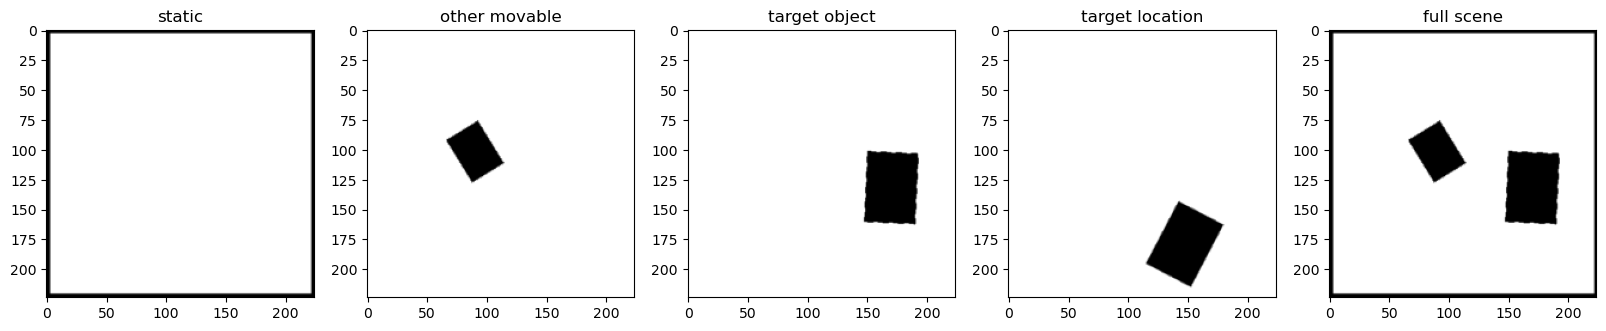

In [54]:
idx = np.random.randint(0, len(train_dataset))
d = train_dataset[idx]
fig, ax = plt.subplots(1, 5, figsize=(20, 20))
titles = ['static', 'other movable', 'target object', 'target location', 'full scene']
for i in range(5):
    ax[i].imshow(d[0][i], cmap='gray')
    ax[i].set_title(titles[i])
d[2] * 30

In [20]:
# build a cnn model for classification
import torch.nn as nn

class FeasibilityClassifier(nn.Module):
    def __init__(self):
        super(FeasibilityClassifier, self).__init__()
        
        # Convolutional layers
        self.conv_layers = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        # Fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc_layers(x)
        return x
    
model = FeasibilityClassifier()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.BCELoss()
# criterion2 = nn.MSELoss()

In [21]:
from torch.optim.lr_scheduler import ReduceLROnPlateau


# data
data_folder = "/media/dhruv/a7519aee-b272-44ae-a117-1f1ea1796db6/2024/NAMO/test1/data_h5/0"
success_path = os.path.join(data_folder, 'success.h5')
failure_path = os.path.join(data_folder, 'failure.h5')
all_data = [success_path, failure_path]

train_dataset = FeasibilityDataset(all_data, mode='train')
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=False)

test_dataset = FeasibilityDataset(all_data, mode='test')
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=False)

# Early stopping parameters
patience = 50
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None


# Training loop
num_epochs = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Add learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_running_loss = 0.0
    
    for images, labels, target in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
        images = images.to(device)
        labels = labels.to(device).float()
        target = target.to(device).float()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        # loss = criterion2(outputs, target)
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_running_loss += loss.item()
    
    train_epoch_loss = train_running_loss / len(train_dataloader)
    
    # Validation phase
    model.eval()
    val_running_loss = 0.0
    
    with torch.no_grad():
        for images, labels, target in tqdm(test_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
            images = images.to(device)
            labels = labels.to(device).float()
            target = target.to(device).float()
            outputs = model(images)
            loss = criterion(outputs, labels)
            # loss = criterion2(outputs, target)
            val_running_loss += loss.item()
    
    val_epoch_loss = val_running_loss / len(test_dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}")

    # Learning rate scheduling
    scheduler.step(val_epoch_loss)
    

    # Early stopping
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

# save the model
torch.save(best_model_state, 'feasibility_classifier_1.pth')

Epoch 1/100 - Validation: 100%|██████████| 37/37 [00:07<00:00,  4.67it/s]


Epoch [1/100], Train Loss: 0.6731, Val Loss: 0.7562


Epoch 2/100 - Validation: 100%|██████████| 37/37 [00:07<00:00,  4.69it/s]


Epoch [2/100], Train Loss: 0.6497, Val Loss: 0.7397


Epoch 3/100 - Validation: 100%|██████████| 37/37 [00:07<00:00,  4.70it/s]


...

Epoch [5/100], Train Loss: 0.6219, Val Loss: 0.6507


Epoch 6/100 - Validation: 100%|██████████| 37/37 [00:07<00:00,  4.69it/s]


Epoch [6/100], Train Loss: 0.5999, Val Loss: 0.9126


Epoch 7/100 - Training:  73%|███████▎  | 239/327 [01:02<00:22,  3.85it/s]


KeyboardInterrupt: 

In [27]:
model.load_state_dict(torch.load('feasibility_classifier_1.pth'))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/tmp/ipykernel_34744/445959542.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('feasibility_classifier_1.pth'))


FeasibilityClassifier(
  (conv_layers): Sequential(
    (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=50176, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout

Button(description='Next', style=ButtonStyle())

Output()

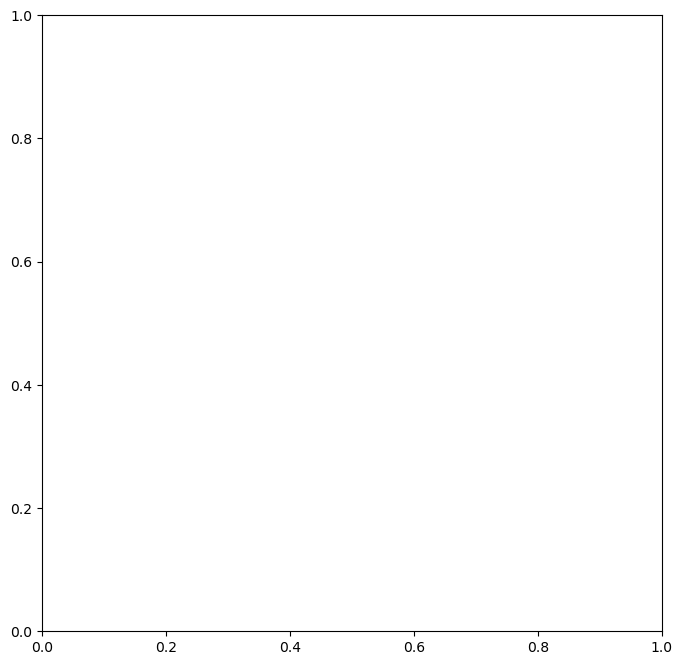

In [29]:
from IPython.display import display, clear_output
import ipywidgets as widgets

model.eval()
# Create widgets
fig, ax = plt.subplots(figsize=(8, 8))
button = widgets.Button(description="Next")
output = widgets.Output()

# Display widgets once
display(button, output)

# Iterator for the dataloader
vis_test_dataloader = iter(DataLoader(test_dataset, batch_size=1, shuffle=True, pin_memory=False))

def show_next_image(b):
    with output:
        clear_output(wait=True)
        try:
            # Get next batch
            images, labels, target = next(vis_test_dataloader)
            
            
            # Show image
            ax.clear()
            ax.imshow((images[0].permute(1, 2, 0) + 1) / 2)
            display(fig)
            
            # Process prediction
            images = images.to(device)
            labels = labels.to(device).float()
            target = target.to(device).float()
            with torch.no_grad():
                outputs = model(images)
            # print("prediction: ", np.round(outputs[0].item(), 2), "label: ", labels[0].item())
            # print(((outputs[0].item() > 0.5) * 1.0) == (labels[0].item() * 1.0))
            print(outputs[0].item(), target[0].item())
            # print((outputs > 0.5) == labels, )
            
        except StopIteration:
            print("End of dataset reached")
            button.disabled = True

# Connect button to function
button.on_click(show_next_image)

In [35]:
vis_test_dataloader = iter(DataLoader(test_dataset, batch_size=1, shuffle=True, pin_memory=False))
model.eval()
correct_pred = 0
total_pred = 0
for img, label in tqdm(vis_test_dataloader):
    img = img.to(device)
    label = label.to(device).float()
    with torch.no_grad():
        outputs = model(img)
    if ((outputs > 0.5) * 1.0) == (label.item() * 1.0):
        correct_pred += 1
    total_pred += 1
print(f"Accuracy: {correct_pred / total_pred * 100:.2f}%")


100%|██████████| 40/40 [00:00<00:00, 143.20it/s]

Accuracy: 90.00%
